# Health Insurance Premium Prediction **Project**

#### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import plotly.express as px
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

Uploading the dataset


In [2]:
df = pd.read_csv("/content/Health_insurance.csv")

Looking at the first 10 rows of the dataset

In [3]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Checking for null values

In [4]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Checking data types of each columns and non-Null Count

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Plotting a Histogram to show count of male and female Smokers and Non Smokers

In [6]:
figure = px.histogram(df, x = "sex", color = "smoker", title= "Number of Smokers")
figure.show()

Mapping the values


In [7]:
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

Checking the changes for first 20 rows


In [8]:
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
5,31,0,25.740,0,0,southeast,3756.62160
6,46,0,33.440,1,0,southeast,8240.58960
7,37,0,27.740,3,0,northwest,7281.50560
8,37,1,29.830,2,0,northeast,6406.41070
9,60,0,25.840,0,0,northwest,28923.13692


Creating a pie chart for showing population by region

In [9]:
pie = df["region"].value_counts()
regions = pie.index
population = pie.values
fig = px.pie(df, values=population, names=regions)
fig.show()

Correlation Matrix

In [10]:
corr = df.select_dtypes(include=["number"]).corr()
corr

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


One-Hot Encoding

In [11]:
df = pd.get_dummies(df, columns=["region"], drop_first=True)

Train-Test Splitting

In [12]:
x = df.drop("charges", axis=1)
y = df["charges"]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.15, random_state=42)

Random Forest Regressor Model with GridSearchCV





In [13]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

forest = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Train the models
grid_search.fit(xtrain, ytrain)

# Get the best trained model
forest = grid_search.best_estimator_

# Predictions
ypred = forest.predict(xtest)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best Parameters are :

In [14]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


Best Cross Validation R²

In [15]:
print("Best Cross Validation R²:", grid_search.best_score_)

Best Cross Validation R²: 0.8302149459002383


Making Prediction using Model

In [16]:
results = pd.DataFrame({
    "Actual Charges": ytest,
    "Predicted Charges": ypred
})

results["Absolute Error"] = (
    results["Actual Charges"] - results["Predicted Charges"]
).abs()

results = results.reset_index(drop=True)

print(results.head(10))

   Actual Charges  Predicted Charges  Absolute Error
0      9095.06825       10418.165781     1323.097531
1      5272.17580        5320.987444       48.811644
2     29330.98315       28039.384810     1291.598340
3      9301.89355       10987.237238     1685.343688
4     33750.29180       34731.171635      980.879835
5      4536.25900        8040.196763     3503.937763
6      2117.33885        2109.477005        7.861845
7     14210.53595       14710.710302      500.174352
8      3732.62510        7026.993925     3294.368825
9     10264.44210       11127.662954      863.220854


Plot between Actual Value vs. Predicted Value

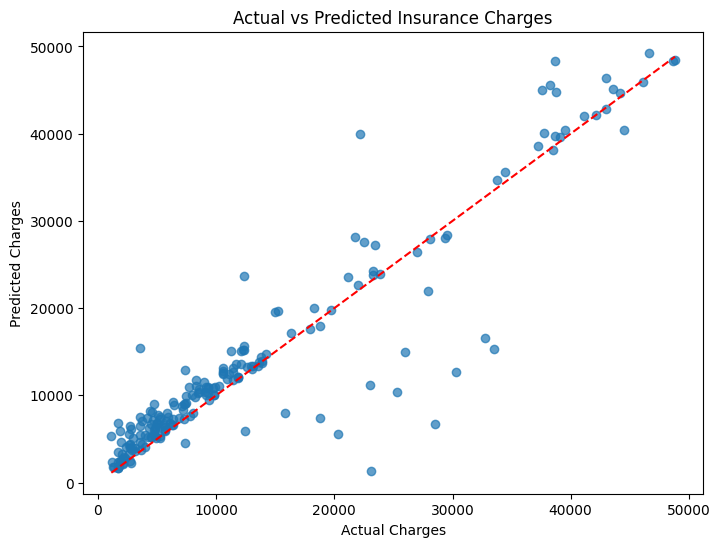

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(ytest, ypred, alpha=0.7)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    'r--'
)
plt.show()

Performance Metrics

In [18]:
r2 = r2_score(ytest, ypred)
mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(ytest, ypred)

print("R² Score :", r2)
print("MAE       :", mae)
print("MSE       :", mse)
print("RMSE      :", rmse)
print("MAPE      :", mape)

R² Score : 0.8582279767173254
MAE       : 2586.2250601082474
MSE       : 21587304.18850557
RMSE      : 4646.213962841743
MAPE      : 0.3233014640807263


Creating a new data





In [19]:
new_data = pd.DataFrame({
    "age": [36],
    "sex": [1],
    "bmi": [27],
    "children": [2],
    "smoker": [0],
    "region_northwest": [0],
    "region_southeast": [1],
    "region_southwest": [0]
})

Prediction on new data

In [20]:
prediction = forest.predict(new_data)

Predicted Premium Value

In [21]:
print(prediction[0])

6779.3604730173665
